# Check combined single-cell profiles for excess NaNs by well/FOV/timepoint

Scans every parquet file in `5.combined_profiles` and, for each `Well_FOV_Time` group, measures the fraction of feature values that are NaN. Timepoints whose NaN fraction is an outlier relative to the rest of that well/FOV's timelapse are flagged as candidates for re-running segmentation/feature extraction.

## Import libraries

In [1]:
import logging
import os
import pathlib

import numpy as np
import pandas as pd
from timelapse_utils.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
root_dir, in_notebook = init_notebook()
if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm

## Set paths and variables

In [ ]:
if in_notebook:
    import tqdm.notebook as tqdm

    plate_name = "plate_2"
else:
    import tqdm

    argparser = argparse.ArgumentParser()

    argparser.add_argument(
        "--plate_name",
        type=str,
        help="Name of the plate to analyze",
    )
    args = argparser.parse_args()
    plate_name = args.plate_name

In [ ]:
image_base_dir = bandicoot_check(
    bandicoot_mount_path=pathlib.Path(f"{os.path.expanduser('~')}/mnt/bandicoot/"),
    root_dir=root_dir,
)
image_base_dir = root_dir / "data"
image_base_dir = pathlib.Path(f"{image_base_dir}/processed_data/").resolve(strict=True)
combined_profiles_path = image_base_dir / "6.combined_profiles"

nan_qc_path = image_base_dir / "7.qc_profiles" / plate_name / "nan_qc"
nan_qc_path.mkdir(parents=True, exist_ok=True)

# a well/FOV/timepoint is flagged if its mean per-row NaN fraction exceeds
# the well/FOV's median NaN fraction by more than this many median absolute
# deviations (MADs), a robust outlier threshold that tolerates a baseline
# level of expected missingness (e.g. unmatched-nucleus rows)
mad_threshold = 5.0

## Helper function

In [3]:
def compute_nan_fractions_per_timepoint(df: pd.DataFrame) -> pd.DataFrame:
    """
    Description
    -----------
    Computes the mean per-row NaN fraction (across feature columns only, excluding
    Metadata_* columns) for each Metadata_Time group in a single well/FOV profile.

    Parameters
    ----------
    df : pd.DataFrame
        A single well/FOV combined single-cell profile.

    Returns
    -------
    pd.DataFrame
        One row per Metadata_Time with the number of cells and mean NaN fraction.
    """
    feature_cols = [c for c in df.columns if not c.startswith("Metadata_")]
    row_nan_frac = df[feature_cols].isna().mean(axis=1)
    out = (
        pd.DataFrame(
            {
                "Metadata_Time": df["Metadata_Time"].astype(str),
                "row_nan_frac": row_nan_frac,
            }
        )
        .groupby("Metadata_Time")
        .agg(n_cells=("row_nan_frac", "size"), mean_nan_frac=("row_nan_frac", "mean"))
        .reset_index()
    )
    return out

## Scan all combined profiles for excess NaNs

In [4]:
all_results = []

parquet_files = sorted(combined_profiles_path.glob("*.parquet"))
for file_path in tqdm.tqdm(
    parquet_files, desc="Scanning combined profiles", unit="file", leave=True
):
    well_fov = file_path.stem
    df = pd.read_parquet(file_path)

    per_time = compute_nan_fractions_per_timepoint(df)
    per_time["Metadata_Well_FOV"] = well_fov

    # robust outlier detection: median absolute deviation of the NaN fraction
    # across timepoints within this well/FOV
    median_frac = per_time["mean_nan_frac"].median()
    mad = (per_time["mean_nan_frac"] - median_frac).abs().median()
    # avoid divide-by-zero when a well/FOV has no NaNs at all
    scaled_mad = mad if mad > 0 else 1e-9
    per_time["nan_frac_mad_score"] = (
        per_time["mean_nan_frac"] - median_frac
    ).abs() / scaled_mad
    per_time["needs_rerun"] = (per_time["nan_frac_mad_score"] > mad_threshold) & (
        per_time["mean_nan_frac"] > median_frac
    )

    all_results.append(per_time)

nan_qc_df = pd.concat(all_results, ignore_index=True)
nan_qc_df = nan_qc_df[
    [
        "Metadata_Well_FOV",
        "Metadata_Time",
        "n_cells",
        "mean_nan_frac",
        "nan_frac_mad_score",
        "needs_rerun",
    ]
].sort_values(["Metadata_Well_FOV", "Metadata_Time"])
nan_qc_df

Scanning combined profiles:   0%|          | 0/224 [00:00<?, ?file/s]

,Metadata_Well_FOV,Metadata_Time,n_cells,mean_nan_frac,nan_frac_mad_score,needs_rerun
0,B2_1,1,1183,0.003414,0.000000e+00,False
1,B2_1,10,1323,0.003414,4.336809e-10,False
2,B2_1,100,2099,0.003414,0.000000e+00,False
3,B2_1,101,2117,0.003414,0.000000e+00,False
4,B2_1,102,2104,0.003414,0.000000e+00,False
...,...,...,...,...,...,...
22800,O5_4,95,1517,0.003414,4.336809e-10,False
22801,O5_4,96,1552,0.003414,0.000000e+00,False
22802,O5_4,97,1537,0.003414,0.000000e+00,False
22803,O5_4,98,1522,0.003414,0.000000e+00,False


## Save full per-timepoint NaN QC table

In [5]:
nan_qc_df.to_parquet(nan_qc_path / "nan_qc_per_well_fov_timepoint.parquet", index=False)
nan_qc_df.to_csv(nan_qc_path / "nan_qc_per_well_fov_timepoint.csv", index=False)

## Summarize well/FOV/timepoints flagged for potential rerun

In [6]:
flagged_df = nan_qc_df.loc[nan_qc_df["needs_rerun"]].copy()
flagged_df = flagged_df.sort_values("nan_frac_mad_score", ascending=False)

flagged_df.to_csv(nan_qc_path / "flagged_for_rerun.csv", index=False)

print(f"Flagged {len(flagged_df)} well/FOV/timepoints out of {len(nan_qc_df)} total")
print(f"Affecting {flagged_df['Metadata_Well_FOV'].nunique()} unique well/FOVs")
flagged_df

Flagged 2373 well/FOV/timepoints out of 22805 total
Affecting 213 unique well/FOVs


,Metadata_Well_FOV,Metadata_Time,n_cells,mean_nan_frac,nan_frac_mad_score,needs_rerun
11137,H5_2,28,1239,0.003447,1.524989e+14,True
11161,H5_2,5,1067,0.003446,1.475681e+14,True
11194,H5_2,8,1070,0.003440,1.177235e+14,True
11183,H5_2,7,1071,0.003440,1.176135e+14,True
11138,H5_2,29,1249,0.003439,1.134585e+14,True
...,...,...,...,...,...,...
3598,D2_4,34,1084,0.003506,5.145890e+00,True
3602,D2_4,38,1084,0.003506,5.145890e+00,True
8165,G2_1,15,1222,0.003501,5.077144e+00,True
3910,D3_3,4,1287,0.003526,5.043917e+00,True


In [7]:
from natsort import natsort_keygen

nan_qc_df = nan_qc_df.sort_values(
    ["Metadata_Well_FOV", "Metadata_Time"], key=natsort_keygen()
).reset_index(drop=True)
nan_qc_df

,Metadata_Well_FOV,Metadata_Time,n_cells,mean_nan_frac,nan_frac_mad_score,needs_rerun
0,B2_1,1,1183,0.003414,0.000000e+00,False
1,B2_1,2,1189,0.003414,4.336809e-10,False
2,B2_1,3,1206,0.003414,4.336809e-10,False
3,B2_1,4,1233,0.003423,8.307212e+03,True
4,B2_1,5,1240,0.003414,0.000000e+00,False
...,...,...,...,...,...,...
22800,O5_4,98,1522,0.003414,0.000000e+00,False
22801,O5_4,99,1542,0.003414,0.000000e+00,False
22802,O5_4,100,1541,0.003414,0.000000e+00,False
22803,O5_4,101,1551,0.003414,0.000000e+00,False


In [8]:
# drop time rows that contina T
nan_qc_df.loc[nan_qc_df["Metadata_Time"].str.contains("T"), "Metadata_Time"] = np.nan
nan_qc_df.dropna(subset=["Metadata_Time"], inplace=True)
nan_qc_df["Metadata_Time"] = nan_qc_df["Metadata_Time"].astype(float).astype(int)

In [9]:
flagged_df
# drop time rows that contina T
flagged_df.loc[flagged_df["Metadata_Time"].str.contains("T"), "Metadata_Time"] = np.nan
flagged_df.dropna(subset=["Metadata_Time"], inplace=True)
flagged_df["Metadata_Time"] = flagged_df["Metadata_Time"].astype(float).astype(int)

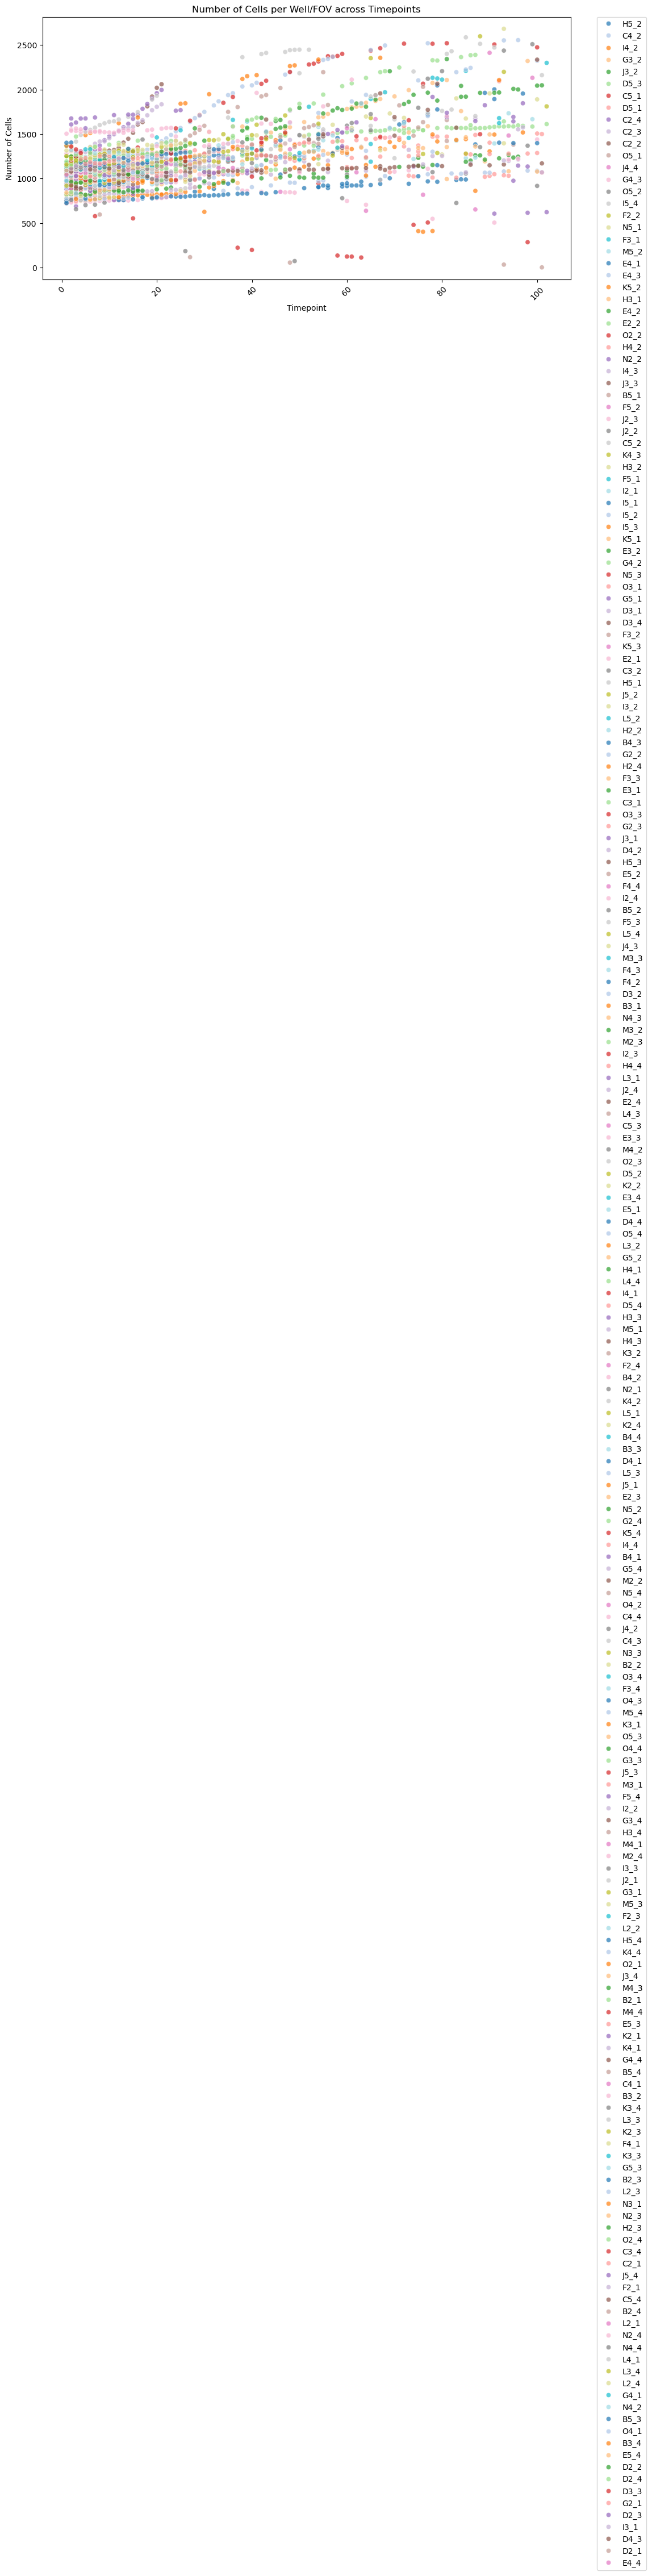

In [10]:
# plot all well fopvs across time on the x and cells on the y
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    # data=nan_qc_df,
    data=flagged_df,
    x="Metadata_Time",
    y="n_cells",
    hue="Metadata_Well_FOV",
    palette="tab20",
    alpha=0.7,
)
plt.title("Number of Cells per Well/FOV across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("Number of Cells")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.show()